# Экспоненциальный рост
**Цель:** Исследовать решение уравнения du/dt = αu.

## Инициализация проекта и загрузка пакетов

In [1]:
using DrWatson
@quickactivate "project"

using DifferentialEquations
using Plots
using DataFrames
using JLD2

script_name = "01_exponential_growth"
mkpath(plotsdir(script_name))
mkpath(datadir(script_name))

"C:\\Users\\uzarb\\work\\study\\2026-1\\2026-1==study-simulation-modeling\\labs\\lab01\\project\\data\\01_exponential_growth"

## Определение модели
Уравнение экспоненциального роста:
du/dt = αu, u(0) = u0

In [2]:
function exponential_growth!(du, u, p, t)
    α = p
    du[1] = α * u[1]
end

exponential_growth! (generic function with 1 method)

## Первый запуск с параметрами по умолчанию
Зададим начальные параметры:

In [3]:
u0 = [1.0]           # начальная популяция
α = 0.3              # скорость роста
tspan = (0.0, 10.0)   # временной интервал

prob = ODEProblem(exponential_growth!, u0, tspan, α)
sol = solve(prob, Tsit5(), saveat=0.1)

retcode: Success
Interpolation: 1st order linear
t: 101-element Vector{Float64}:
  0.0
  0.1
  0.2
  0.3
  0.4
  0.5
  0.6
  0.7
  0.8
  0.9
  1.0
  1.1
  1.2
  ⋮
  8.9
  9.0
  9.1
  9.2
  9.3
  9.4
  9.5
  9.6
  9.7
  9.8
  9.9
 10.0
u: 101-element Vector{Vector{Float64}}:
 [1.0]
 [1.030454533950446]
 [1.0618365551529674]
 [1.0941743028794098]
 [1.1274968605386673]
 [1.1618342327450653]
 [1.1972173476990624]
 [1.233678057187257]
 [1.2712491879500347]
 [1.3099646073864084]
 [1.3498590188273822]
 [1.390968273354968]
 [1.4333293964993763]
 ⋮
 [14.439892233074872]
 [14.87962750503581]
 [15.33275596650523]
 [15.79968870415309]
 [16.280848966976613]
 [16.776672166300525]
 [17.287605875776965]
 [17.814109831385352]
 [18.35665593143248]
 [18.91572823655283]
 [19.491822969707854]
 [20.08544851618676]

## Визуализация результатов
Построим график решения:

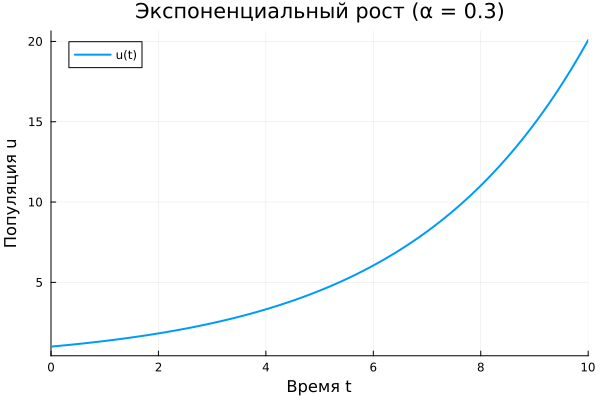

In [4]:
plot(sol, label="u(t)", xlabel="Время t", ylabel="Популяция u",
     title="Экспоненциальный рост (α = $α)", lw=2, legend=:topleft)

Сохраним график в папку plots

In [5]:
savefig(plotsdir(script_name, "exponential_growth_α=$α.png"))

"C:\\Users\\uzarb\\work\\study\\2026-1\\2026-1==study-simulation-modeling\\labs\\lab01\\project\\plots\\01_exponential_growth\\exponential_growth_α=0.3.png"

## Анализ результатов
Создадим таблицу с данными:

In [6]:
df = DataFrame(t=sol.t, u=first.(sol.u))
println("Первые 5 строк результатов:")
println(first(df, 5))

Первые 5 строк результатов:
5×2 DataFrame
 Row │ t        u       
     │ Float64  Float64 
─────┼──────────────────
   1 │     0.0  1.0
   2 │     0.1  1.03045
   3 │     0.2  1.06184
   4 │     0.3  1.09417
   5 │     0.4  1.1275


Вычислим удвоение популяции:

In [7]:
u_final = last(sol.u)[1]
doubling_time = log(2) / α
println("\nАналитическое время удвоения: ", round(doubling_time; digits=2))


Аналитическое время удвоения: 2.31


## Сохранение всех результатов

In [8]:
@save datadir(script_name, "all_results.jld2") df

---

*This notebook was generated using [Literate.jl](https://github.com/fredrikekre/Literate.jl).*